# Load Pinyin Labelled Corpus

In [1]:
import pandas as pd


dataset = pd.read_csv("/kaggle/input/notebooks/davidvista/pinyin-dataset-labelling/chinese-short-sentences-pinyin.csv")

In [2]:
dataset.head()

,text,pinyin
0,一个特殊群体的期待在密切关注此次特金会的人中有一个特殊的群体在日本殖民期间来到日本的韩国朝鲜...,yi1 ge4 te4 shu1 qun2 ti3 de qi1 dai4 zai4 mi4...
1,他们希望政治解冻有助于让朝鲜摆脱孤立,ta1 men xi1 wang4 zheng4 zhi4 jie3 dong4 you3 ...
2,他认为对这个奖的妄想可能会促使双方做出轻率的承诺但也可能有助于艰巨的和平进程,ta1 ren4 wei2 dui4 zhe4 ge4 jiang3 de wang4 xi...
3,欢迎阅读纪思道文章的中文版,huan1 ying2 yue4 du2 ji4 si1 dao4 wen2 zhang1 ...
4,不法业者向一些中国女性编造了一个美好的未来到美国开始新生活并拥有一份合法的工作,bu4 fa3 ye4 zhe3 xiang4 yi1 xie1 zhong1 guo2 n...


## Examine Pinyin Tokens

### Compute Statistics

In [3]:
from collections import Counter
import pandas as pd
from tqdm import tqdm


pinyin_counter = Counter()

for pinyin_str in tqdm(dataset['pinyin']):
    # Split by space and update counter
    pinyin_counter.update(pinyin_str.split())

# Convert to DataFrame for easier viewing
pinyin_counts = pd.DataFrame(pinyin_counter.items(), columns=['pinyin', 'count']).sort_values('count', ascending=False)

print(pinyin_counts.head(10))

100%|██████████| 161521/161521 [00:00<00:00, 250462.84it/s]

     pinyin   count
6        de  216603
176    shi4  114807
0       yi1   76502
9      zai4   72786
82      bu4   58563
29     guo2   57669
19   zhong1   57157
18     ren2   50422
34      ta1   47794
52     zhe4   45882


In [4]:
len(pinyin_counts)

1103

### Cumulative Plot

In [5]:
pinyin_counts = pinyin_counts.sort_values(by='count', ascending=False)

pinyin_counts['freq'] = pinyin_counts['count'].cumsum()
pinyin_counts['freq'] /= pinyin_counts['count'].sum()

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style()

In [7]:
# 99-Percentile
import numpy as np

k = np.argmax(pinyin_counts['freq'] > 0.99)

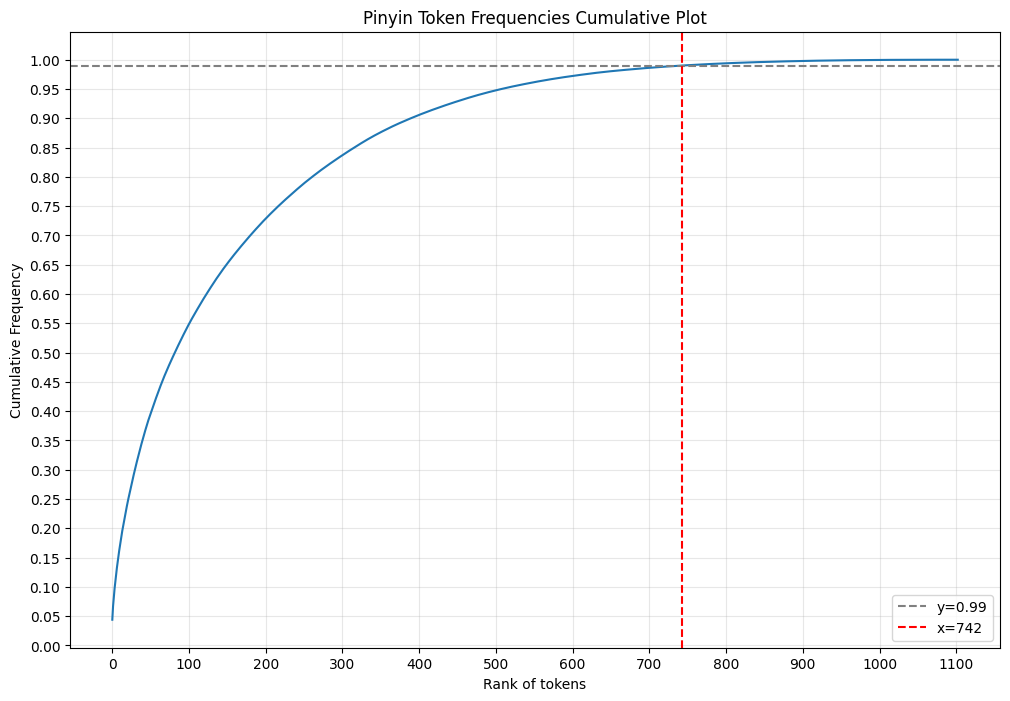

In [8]:
plt.figure(figsize=(12, 8))
plt.title("Pinyin Token Frequencies Cumulative Plot")

plt.xlabel("Rank of tokens")
plt.ylabel("Cumulative Frequency")

plt.xticks(range(0, 1200, 100))
plt.yticks(np.arange(0, 1.05, 0.05))

plt.plot(range(len(pinyin_counts)), pinyin_counts['freq'])

plt.axhline(y=0.99, linestyle='--', color='grey', label='y=0.99')
plt.axvline(x=k, linestyle='--', color='red', label=f"x={k}")

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Neutral Tone Tokens

The following pinyin tokens are of fifth (neural) tone:

In [9]:
pinyin_counts[
    pinyin_counts['pinyin'].transform(lambda x: x[-1].isalpha())
]

,pinyin,count,freq
6,de,216603,0.043929
92,le,43183,0.170638
35,men,35361,0.210011
374,zhe,9999,0.614822
388,zi,9199,0.637978
364,me,7138,0.711980
927,ba,568,0.983695
550,ma,543,0.984935
728,ne,336,0.992335
421,a,132,0.997855


Some tokens are quite rare, so the examples are analyzed:

1. `tou` - 石头

In [10]:
with pd.option_context('display.max_colwidth', None):

    tou_data = dataset[
        dataset['pinyin'].str.split().apply(lambda x: 'tou' in x)
    ]
    
    print(tou_data.head(3))

    print(f"Number of occurences: {len(tou_data)}")

                       text  \
6962     说得明白些我们不只是在谈论石头和建筑   
19701   今天早晨我写信时他把罐头起子按到我腿上   
20209  他们不担心有人扔石头因为这很容易处理他说   

                                                                                               pinyin  
6962           shuo1 de2 ming2 bai2 xie1 wo3 men bu4 zhi3 shi4 zai4 tan2 lun4 shi2 tou he2 jian4 zhu4  
19701      jin1 tian1 zao3 chen2 wo3 xie3 xin4 shi2 ta1 ba3 guan4 tou qi3 zi an4 dao4 wo3 tui3 shang4  
20209  ta1 men bu4 dan1 xin1 you3 ren2 zhi2 shi2 tou yin1 wei4 zhe4 hen3 rong2 yi4 chu3 li3 ta1 shuo1  
Number of occurences: 77


2. `bo` - prediction error (<0.05% of examples are to be removed from corpus)

In [11]:
with pd.option_context('display.max_colwidth', None):

    bo_data = dataset[
        dataset['pinyin'].str.split().apply(lambda x: 'bo' in x)
    ]
    
    print(bo_data.head(3))

    print(f"Number of occurences: {len(bo_data)}")

                                               text  \
1273          纽约时报 现年82岁的阿尔及利亚強人总统阿卜杜勒阿齐兹布特弗利卡月底将下台   
1376                       如今安倍的政治对手已经磨刀霍霍安倍经济学命运未卜   
1447  纽约时报 马尔代夫总统易卜拉欣穆罕默德萨利赫所在的政党似乎将在该国议会选举中获得压倒性胜利   

                                                                                                                                                                                                                       pinyin  
1273                                                  niu3 yue1 shi2 bao4 bu4 xian4 nian2 hu2 shou4 sui4 de a1 er3 ji2 li4 ya4 liao2 ren2 zong3 tong3 a1 bo du4 lei1 a1 qi2 zi1 bu4 te4 fu2 li4 ka3 yue4 di3 jiang1 xia4 tai2  
1376                                                                                                      ru2 jin1 an1 bei4 de zheng4 zhi4 dui4 shou3 yi3 jing1 mo2 dao1 huo4 huo4 an1 bei4 jing1 ji4 xue2 ming4 yun4 wei4 bo  
1447  niu3 yue1 shi2 bao4 bu4 ma3 er3 dai4 fu1 zong3 tong3 yi4 bo la1 xin1 mu4 han3 mo4 de2 sa4 li4 he4 suo

3. `shi` - 钥匙

In [12]:
with pd.option_context('display.max_colwidth', None):

    shi_data = dataset[
        dataset['pinyin'].str.split().apply(lambda x: 'shi' in x)
    ]
    
    print(shi_data.head(3))

    print(f"Number of occurences: {len(shi_data)}")

                                           text  \
11661    偏爱这一方式的东西海岸自由派精英自认为垄断了智慧与开启进步之门的唯一一把钥匙   
12498  这些女性发来的照片提供了一把钥匙让我们了解到作为女儿我们有多想看到年轻女性的品质   
16235            我跟他们喝了一杯又一杯直到我把钥匙放进自己公寓里面才晕了过去   

                                                                                                                                                                                                pinyin  
11661                pian1 ai4 zhe4 yi1 fang1 shi4 de dong1 xi1 hai3 an4 zi4 you2 pai4 jing1 ying1 zi4 ren4 wei2 long3 duan4 le zhi4 hui4 yu3 kai1 qi3 jin4 bu4 zhi1 men2 de wei2 yi1 yi1 ba3 yao4 shi  
12498  zhe4 xie1 nv3 xing4 fa1 lai2 de zhao4 pian4 ti2 gong1 le yi1 ba3 yao4 shi rang4 wo3 men liao3 jie3 dao4 zuo4 wei2 nv3 er2 wo3 men you3 duo1 xiang3 kan4 dao4 nian2 qing1 nv3 xing4 de pin3 zhi4  
16235                                                           wo3 gen1 ta1 men he1 le yi1 bei1 you4 yi1 bei1 zhi2 dao4 wo3 ba3 yao4 shi fang4 jin4 zi4 ji3 gong1 yu4 li3 mian4 cai2 yun1 le gu

4. `shang` - 衣裳

In [13]:
with pd.option_context('display.max_colwidth', None):

    shang_data = dataset[
        dataset['pinyin'].str.split().apply(lambda x: 'shang' in x)
    ]
    
    print(shang_data.head(3))

    print(f"Number of occurences: {len(shang_data)}")

                                                    text  \
10647   事发后我们在镜头里看到他们血迹斑斑的衣裳和玩具扔得到处都是一辆绿色的塑料玩具车孤零零地停在废墟里   
84775                              尽管天气湿热难当保育员还是给她穿了两层衣裳   
128458  雅子穿着一件被称为五衣唐衣裳又称十二单的多层和服其设计可追溯到10世纪多层和服的总重量约15公斤   

                                                                                                                                                                                                                                            pinyin  
10647               shi4 fa1 hou4 wo3 men zai4 jing4 tou2 li3 kan4 dao4 ta1 men xue4 ji4 ban1 ban1 de yi1 shang he2 wan2 ju4 se4 de2 dao4 chu3 dou1 shi4 yi1 liang4 lv4 se4 de su4 liao4 wan2 ju4 che1 gu1 ling2 ling2 di4 ting2 zai4 fei4 xu1 li3  
84775                                                                                                                                  jin4 guan3 tian1 qi4 shi1 re4 nan2 dang1 bao3 yu4 yuan2 hai2 shi4 gei3 ji2 chuan1 le liang3 ceng2 yi1 shang  
128458  ya3 zi chuan1 zh

# Prepare Pinyin Sounds

## Chinese Language Institute Website

The following [website](https://studycli.org/pinyin-chart/) hosts interactive table with pinyin tokens and pronunciations with regard of 4 tones.

The `mp3` file path is `https://studycli.org/wp-content/uploads/mp3/<pinyin><tone>.mp3`

In [14]:
import requests

session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
})

res = session.get("https://studycli.org/wp-content/uploads/mp3/ma1.mp3")

res.status_code

200

In [15]:
filepath = "example.mp3"
with open(filepath, "wb") as f:
    f.write(res.content)

In [16]:
from IPython.display import Audio, display

# Load a local audio file
audio = Audio(filename="example.mp3", autoplay=False)

# Display the player
display(audio)

## Loading Script

In [17]:
import os

OUTPUT_DIR = 'recordings'

os.makedirs(OUTPUT_DIR, exist_ok=True)

session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
})

In [18]:
import requests
from tqdm import tqdm
import time
from urllib.parse import urljoin


BASE_URL = "https://studycli.org/wp-content/uploads/mp3/"

for token in tqdm(pinyin_counts['pinyin']):

    filename = f"{token}.mp3"
    try:
        url = urljoin(BASE_URL, filename)
        resp = session.get(url, timeout=10)
        if resp.status_code == 200:
            filepath = os.path.join(OUTPUT_DIR, filename)
            with open(filepath, "wb") as f:
                f.write(resp.content)
        else:
            print(f"Not found: {filename} (HTTP {resp.status_code})")
    except Exception as e:
        print(f"Error downloading {filename}: {e}")
    time.sleep(0.2)  # be polite

  0%|          | 1/1103 [00:00<14:47,  1.24it/s]

Not found: de.mp3 (HTTP 404)


  1%|          | 11/1103 [00:04<08:21,  2.18it/s]

Not found: le.mp3 (HTTP 404)


  1%|▏         | 16/1103 [00:06<08:43,  2.08it/s]

...

 90%|█████████ | 996/1103 [06:25<00:50,  2.13it/s]

Not found: shi.mp3 (HTTP 404)


 99%|█████████▊| 1088/1103 [06:59<00:06,  2.25it/s]

Not found: shang.mp3 (HTTP 404)


100%|██████████| 1103/1103 [07:04<00:00,  2.60it/s]


In [19]:
from IPython.display import Audio, display

# Load a local audio file
audio = Audio(filename=os.path.join(OUTPUT_DIR, "ma3.mp3"), autoplay=False)

# Display the player
display(audio)

## Neutral Tone Syllables Sound Synthesis

I propose to use inference point from Huggingface to synthesize missing sounds with Qwen-TTS. I already prepared the [dataset](https://www.kaggle.com/datasets/davidvista/synthesized-neutral-tone-pinyin-sounds).

Copy to the recordings:

In [20]:
!cp /kaggle/input/datasets/davidvista/synthesized-neutral-tone-pinyin-sounds/*wav /kaggle/working/recordings

## Save Recordings

In [21]:
import shutil

shutil.make_archive('recordings', 'zip', 'recordings')

'/kaggle/working/recordings.zip'

**Side note**:

The resulting dataset of recordings contains recordings for only 1102 sounds, which is not covering all possible sounds. For example, the following sounds are missing: bai1, ban2, bang2, bo4, bei2, ben2, beng2, beng3, biao2, biao4, bie3, bie4, bian2, bin2, bin3, bing2, bu1, pa3, pai3, pan3, pang3, pou2, pou3, pou4, pei3, pen3, pen4, piao3, pie2, pie3, pie4, pian2, pian3, ping3, ping4, mai1, man1, mang1, mang4, mou1, mou4, mei1, men1, men3, meng1, mie1, mie2, mie3, miu1, miu2, miu3, mian1, min1, min4, ming1, ming3, mu1, fa4, fo1, fo3, fo4, fou1, fou2, fou4.

Nevertheless, the examined tokens are rare in speech:

> DeepSeek: the dataset actually covers all common syllables with their typical tones. The missing tokens are either extremely rare or linguistically invalid.

# Wav2Vec Model

## Prepare Model

In [22]:
import torch
import librosa

# Load model directly
from transformers import AutoProcessor, AutoModelForCTC

MODEL_ID = "jonatasgrosman/wav2vec2-large-xlsr-53-chinese-zh-cn"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForCTC.from_pretrained(MODEL_ID)

preprocessor_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.28G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

In [23]:
!pip install -qU ffmpeg-python

model.safetensors:   0%|          | 0.00/1.28G [00:00<?, ?B/s]

In [24]:
import librosa

def load_sound(file_path, target_sr=16000):
    # librosa loads MP3 via audioread backend
    audio, sr = librosa.load(file_path, sr=target_sr)
    return audio  # numpy array, float32, range [-1, 1]


def get_pinyin_embedding(audio_path, model, processor):
    # Load and resample audio
    speech_array = load_sound(audio_path)

    min_len = int(1.0 * 16000)  # 1.0 seconds
    if len(speech_array) < min_len:
        speech_array = np.pad(speech_array, (0, min_len - len(speech_array)))
    
    # Process audio
    inputs = processor(speech_array, sampling_rate=16000, return_tensors="pt", padding=True)
    
    with torch.no_grad():
        outputs = model(inputs.input_values, output_hidden_states=True)
        # outputs.hidden_states is a tuple of (embedding_output, layer1, ..., layerN)
        # Last layer hidden states: shape (batch, seq_len, hidden_dim)
        hidden = outputs.hidden_states[-1]

    # Mean pooling over time dimension
    embedding = hidden.mean(dim=1).squeeze()
    
    return embedding.numpy()

In [25]:
# Example usage
pinyin_vec = get_pinyin_embedding("recordings/ma1.mp3", model, processor)

In [26]:
pinyin_vec.shape

(1024,)

In [27]:
import numpy as np

def transcribe_pinyin(audio_path, model, processor):
    # Load audio (resample to 16kHz, mono)
    speech_array = load_sound(audio_path)

    min_len = int(1.0 * 16000)  # 1.0 seconds
    if len(speech_array) < min_len:
        speech_array = np.pad(speech_array, (0, min_len - len(speech_array)))
    
    # Process audio
    inputs = processor(speech_array, sampling_rate=16000, return_tensors="pt", padding=True)

    with torch.no_grad():
        logits = model(inputs.input_values).logits  # (1, T, vocab_size)
    
    # CTC decoding: get predicted token ids
    predicted_ids = torch.argmax(logits, dim=-1)  # (1, T)
    
    # Decode to pinyin string (processor automatically handles CTC blank collapse)
    predicted_pinyin = processor.batch_decode(predicted_ids)[0]
    
    return predicted_pinyin

In [28]:
transcribe_pinyin("recordings/qi1.mp3", model, processor)

'妻'

In [29]:
transcribe_pinyin("recordings/ba5.wav", model, processor)

'吧'

In [30]:
transcribe_pinyin("recordings/le5.wav", model, processor)

''

In [31]:
transcribe_pinyin("recordings/a5.wav", model, processor)

''

In [32]:
transcribe_pinyin("recordings/me5.wav", model, processor)

'吗'

In [33]:
transcribe_pinyin("recordings/ma5.wav", model, processor)

'嘛'

## Embed Pinyin Sounds

In [34]:
import os
import glob

def build_token_embedding_map(audio_dir, model, processor, extensions=['.mp3', '.wav']):
    """
    Scan audio_dir for files with given extensions, use filename (without extension) as token name,
    and compute embedding for each.

    Args:
        audio_dir: directory containing audio files (e.g., 'ma1.mp3', 'ni3.wav')
        model, processor: wav2vec2 model and processor
        extensions: list of audio extensions to consider

    Returns:
        embedding_map: dict {token: embedding_numpy_array}
    """
    embedding_map = {}
    # Gather all matching files
    audio_files = []
    for ext in extensions:
        pattern = os.path.join(audio_dir, f'*{ext}')
        audio_files.extend(glob.glob(pattern))
    
    for audio_path in tqdm(audio_files):
        # Extract token name: basename without extension
        basename = os.path.basename(audio_path)
        token = os.path.splitext(basename)[0]   # e.g., 'ma1' from 'ma1.mp3'
        
        # Skip if token appears to be empty or malformed (optional)
        if not token:
            continue
            
        try:
            emb = get_pinyin_embedding(audio_path, model, processor)
            embedding_map[token] = emb
        except Exception as e:
            print(f"Error processing {audio_path}: {e}")
    
    return embedding_map

In [35]:
embedding_map = build_token_embedding_map(OUTPUT_DIR, model, processor)

100%|██████████| 1102/1102 [10:07<00:00,  1.82it/s]


In [36]:
import pickle
with open('pinyin_embeddings.pkl', 'wb') as f:
    pickle.dump(embedding_map, f)

## Evaluation

### Preparation

Prepare decomposed pinyin information for future categorical analysis

In [37]:
INITIALS = [
    "", "b","p","m","f","d","t","n","l","g","k","h",
    "j","q","x","zh","ch","sh","r","z","c","s"
]

FINALS = [
    "a","ai","an","ang","ao","e","ei","en","eng","er",
    "i","ia","ian","iang","iao","ie","in","ing","iong","iu",
    "o","ong","ou",
    "u","ua","uai","uan","uang","ui","un","uo",
    "v","ve","van","vn"
]

TONES = ["1","2","3","4","5"]

ZERO_INITIAL_MAP = {
    # y-series
    "yi":"i",
    "ya":"ia",
    "yao":"iao",
    "ye":"ie",
    "you":"iu",
    "yan":"ian",
    "yin":"in",
    "yang":"iang",
    "ying":"ing",
    "yong":"iong",

    "yu":"v",
    "yue":"ve",
    "yuan":"van",
    "yun":"vn",

    # w-series
    "wu":"u",
    "wa":"ua",
    "wo":"uo",
    "wai":"uai",
    "wei":"ui",
    "wan":"uan",
    "wen":"un",
    "wang":"uang",
    "weng":"ong",
}


def normalize_zero_initial(base):
    return ZERO_INITIAL_MAP.get(base, base)


def normalize_jqx(final):
    if final.startswith("u"):
        mapping = {
            "u": "v",
            "ue": "ve",
            "uan": "van",
            "un": "vn",
        }
        return mapping.get(final, final)
    return final


# init2idx = {v:i for i,v in enumerate(INITIALS)}
# final2idx = {v:i for i,v in enumerate(FINALS)}
# tone2idx = {v:i for i,v in enumerate(TONES)}

# idx2init = {i:v for v,i in init2idx.items()}
# idx2final = {i:v for v,i in final2idx.items()}
# idx2tone = {i:v for v,i in tone2idx.items()}


def decompose_pinyin(token: str):
    tone = token[-1]

    if not tone.isdigit():
        tone = "5" # neutral tone, usually has no digit
        base = token
    else:
        base = token[:-1]

    base = normalize_zero_initial(base)

    # longest-match for initials

    try:
        for ini in sorted(INITIALS, key=len, reverse=True):
            if base.startswith(ini):
                final = base[len(ini):]

                if ini in {"j","q","x"}:
                    final = normalize_jqx(final)
                
                return ini, final, tone
    except Exception:
        raise ValueError("Invalid pinyin token")

In [38]:
decompose_pinyin('ma3')

('m', 'a', '3')

In [39]:
from tqdm import tqdm

# Metadata
token_info = dict()

for pinyin_token in tqdm(list(embedding_map.keys())):
    ini, final, tone = decompose_pinyin(pinyin_token)
    token_info[pinyin_token] = {'initial': ini, 'final': final, 'tone': tone}

100%|██████████| 1102/1102 [00:00<00:00, 335106.43it/s]


In [40]:
token_info['ma3']

{'initial': 'm', 'final': 'a', 'tone': '3'}

Cosine similarity will be used for measuring closeness in the space:

In [41]:
import numpy as np
from itertools import combinations
from scipy.stats import sem, t

def cosine_similarity(a, b):
    """Cosine similarity between two 1D numpy arrays."""
    dot = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return dot / (norm_a * norm_b)

def intra_group_similarity(group_tokens, emb_map, confidence=0.95):
    """
    Pairwise cosine similarities within a group.
    Returns: dict with mean, std, confidence interval, count.
    """
    tokens = [t for t in group_tokens if t in emb_map]
    if len(tokens) < 2:
        return {'mean': None, 'std': None, 'ci_lower': None, 'ci_upper': None, 'count': 0}
    
    sims = []
    for t1, t2 in combinations(tokens, 2):
        sims.append(cosine_similarity(emb_map[t1], emb_map[t2]))
    sims = np.array(sims)
    mean = np.mean(sims)
    std = np.std(sims, ddof=1)
    n = len(sims)
    se = sem(sims) if n > 1 else 0.0
    ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0
    return {
        'sims': sims,
        'mean': mean, 'std': std,
        'ci_lower': mean - ci, 'ci_upper': mean + ci,
        'count': n
    }

def inter_group_similarity(group_a, group_b, emb_map, confidence=0.95):
    """
    Pairwise cosine similarities between two groups.
    """
    tokens_a = [t for t in group_a if t in emb_map]
    tokens_b = [t for t in group_b if t in emb_map]
    if not tokens_a or not tokens_b:
        return {'mean': None, 'std': None, 'ci_lower': None, 'ci_upper': None, 'count': 0}
    
    sims = []
    for t1 in tokens_a:
        for t2 in tokens_b:
            sims.append(cosine_similarity(emb_map[t1], emb_map[t2]))
    sims = np.array(sims)
    mean = np.mean(sims)
    std = np.std(sims, ddof=1)
    n = len(sims)
    se = sem(sims) if n > 1 else 0.0
    ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0
    return {
        'mean': mean, 'std': std,
        'ci_lower': mean - ci, 'ci_upper': mean + ci,
        'count': n
    }

### Baseline: Randomized Similarity

In [42]:
import random

random.seed(0)

total = 0
N = 1000

embeddings = list(embedding_map.values())

for _ in range(N):

    
    a = random.choice(embeddings)
    b = random.choice(embeddings)

    total += cosine_similarity(a, b)

baseline_score = total / N

baseline_score

np.float32(0.7173636)

In [43]:
scores = []

for _ in range(1000):
    total = 0
    N = 1000
    
    embeddings = list(embedding_map.values())
    
    for __ in range(N):
    
        
        a = random.choice(embeddings)
        b = random.choice(embeddings)
    
        total += cosine_similarity(a, b)
    
    baseline_score = total / N

    scores.append(baseline_score)

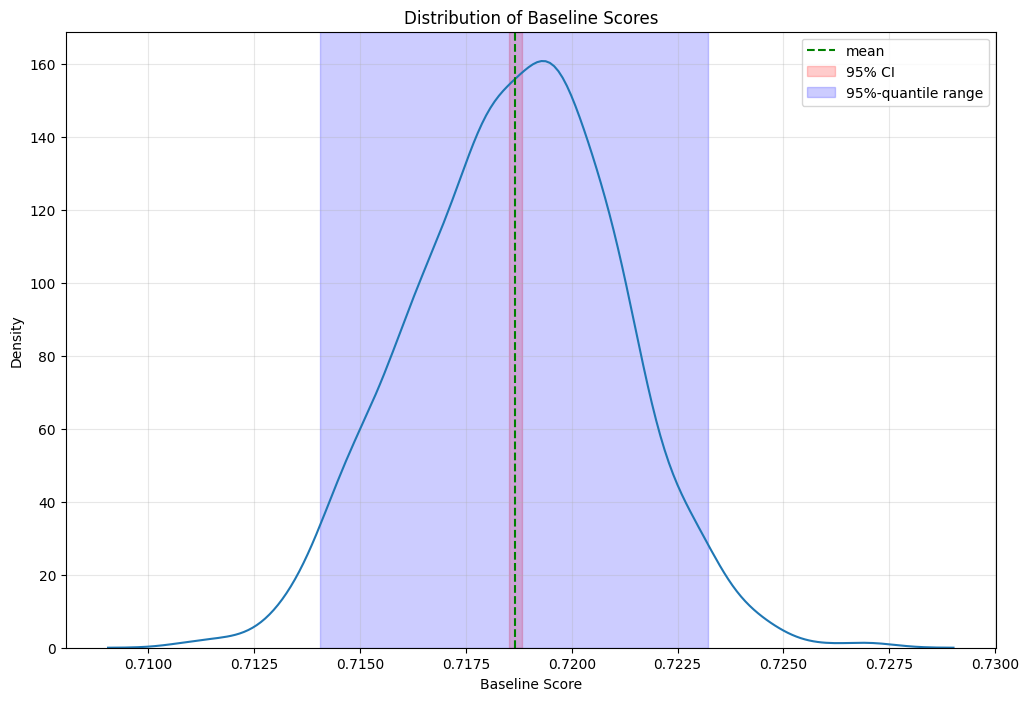

In [44]:
plt.figure(figsize=(12, 8))
plt.title("Distribution of Baseline Scores")

plt.xlabel("Baseline Score")

sns.kdeplot(scores)

n = len(scores)
confidence = 0.95

mean = np.mean(scores)
se = sem(scores) if n > 1 else 0.0
ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0

plt.axvline(mean, linestyle='--', color='green', label='mean')
plt.axvspan(mean-ci, mean+ci, alpha=0.2, color='red', label='95% CI')
plt.axvspan(np.quantile(scores, 0.025), np.quantile(scores, 0.975), alpha=0.2, color='blue', label='95%-quantile range')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Group Analysis (Intra-/Inter-)

In [45]:
# Build lists of tokens that start with each initial
labials   = ['ba1','ba2','ba3','ba4','pa1','pa2','pa3','pa4','ma1','ma2','ma3','ma4','fa1','fa2','fa3','fa4']
alveolars = ['da1','da2','da3','da4','ta1','ta2','ta3','ta4','na1','na2','na3','na4','la1','la2','la3','la4']
dentals   = ['za1','za2','za3','za4','ca1','ca2','ca3','ca4','sa1','sa2','sa3','sa4']
retroflex = ['zha1','zha2','zha3','zha4','cha1','cha2','cha3','cha4','sha1','sha2','sha3','sha4','re1','re2','re3','re4']
palatals  = ['ji1','ji2','ji3','ji4','qi1','qi2','qi3','qi4','xi1','xi2','xi3','xi4']
velars    = ['ga1','ga2','ga3','ga4','ka1','ka2','ka3','ka4','ha1','ha2','ha3','ha4']
null_init = ['a1','a2','a3','a4','o1','o2','o3','o4','e1','e2','e3','e4']
neutral_tone = ['a5', 'ba5', 'de5', 'la5', 'le5', 'ma5', 'me5', 'men5', 'ne5', 'shang5', 'shi5', 'tou5', 'ya5', 'zhe5', 'zi5']


groups = {
    'labials': labials,
    'alveolars': alveolars,
    'dentals': dentals,
    'retroflex': retroflex,
    'palatals': palatals,
    'velars': velars,
    'null_init': null_init,
    'neutral_tone': neutral_tone
}

labials: mean = 0.862 ± 0.062, CI = [0.849, 0.875]
alveolars: mean = 0.880 ± 0.037, CI = [0.872, 0.889]
dentals: mean = 0.860 ± 0.053, CI = [0.836, 0.884]
retroflex: mean = 0.838 ± 0.056, CI = [0.823, 0.854]
palatals: mean = 0.761 ± 0.070, CI = [0.744, 0.778]
velars: mean = 0.851 ± 0.041, CI = [0.828, 0.873]
null_init: mean = 0.893 ± 0.031, CI = [0.815, 0.971]
neutral_tone: mean = 0.786 ± 0.067, CI = [0.773, 0.799]


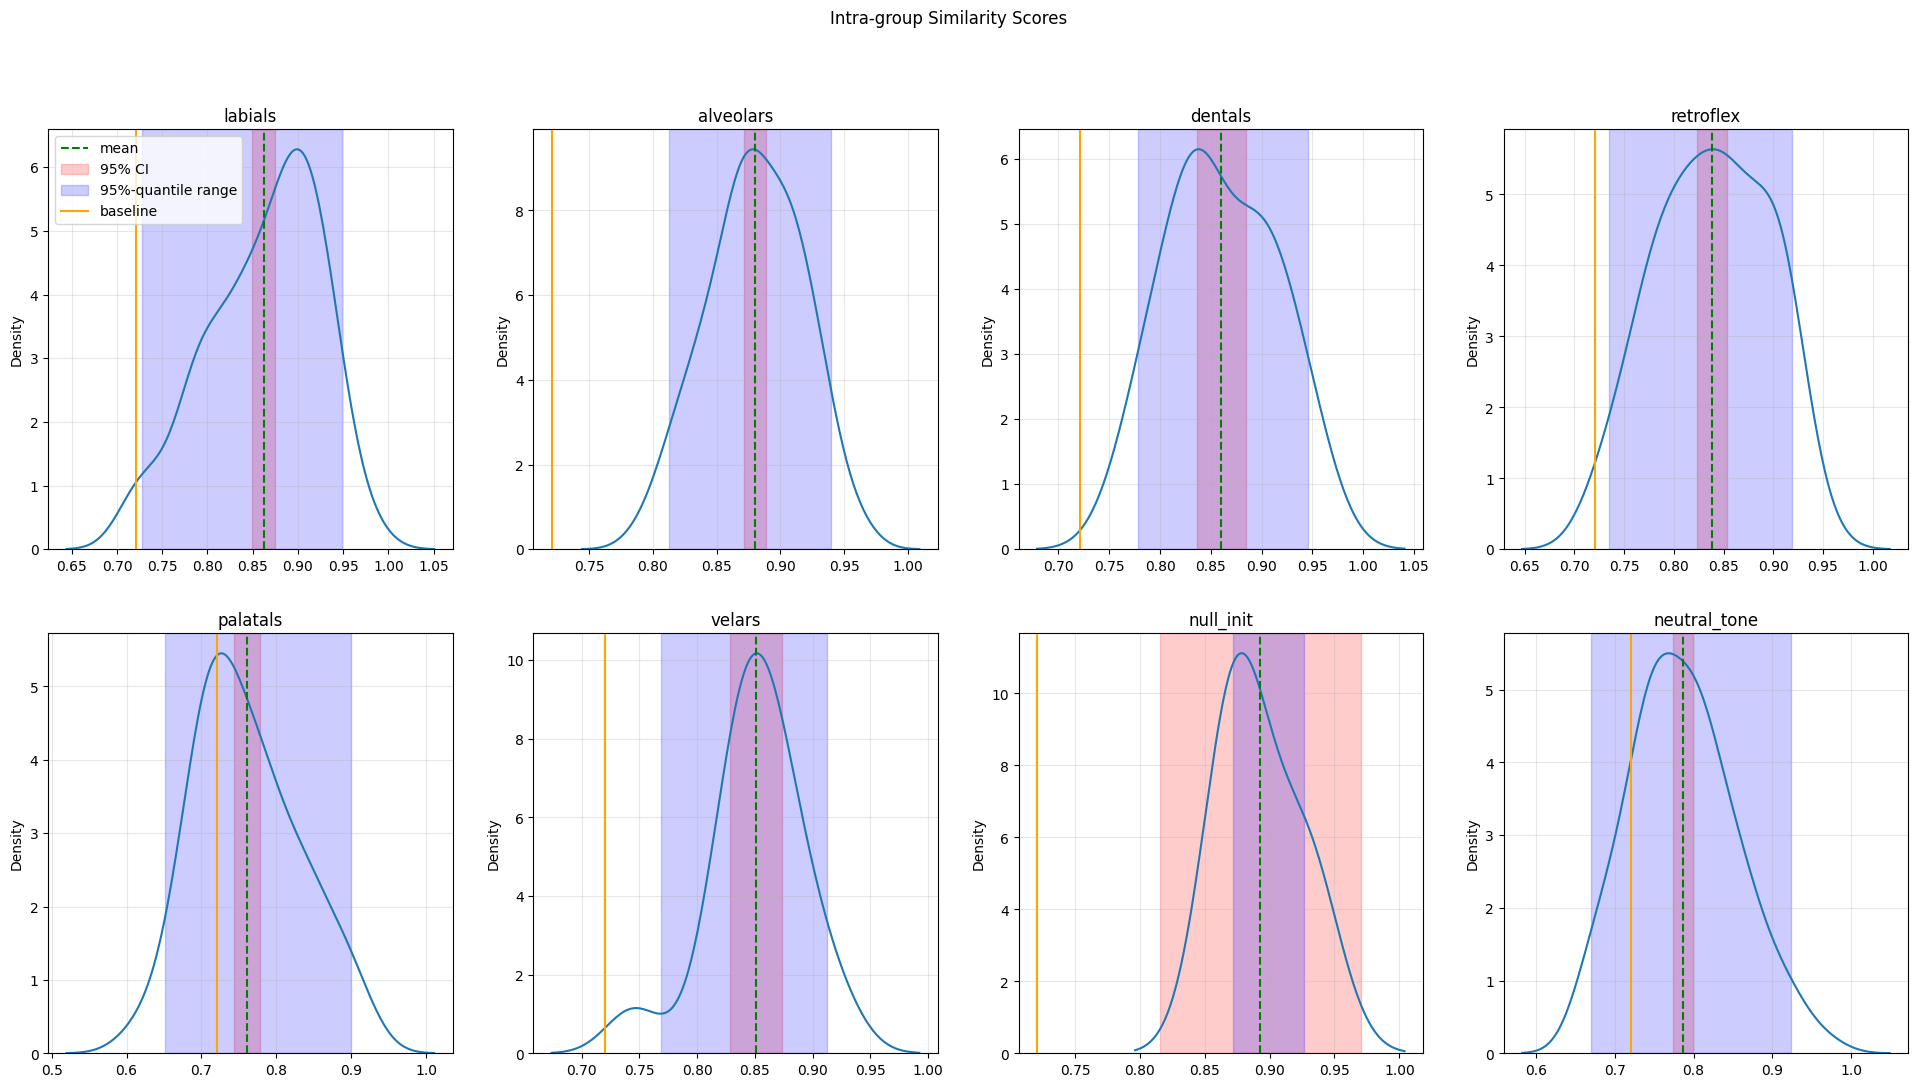

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(24, 12))

fig.suptitle("Intra-group Similarity Scores")

for i, (name, group) in enumerate(groups.items()):
    res = intra_group_similarity(group, embedding_map)

    ax_i = ax[i // 4, i % 4]

    ax_i.set_title(name)
    sns.kdeplot(res['sims'], ax=ax_i)

    ax_i.axvline(res['mean'], color='green', linestyle='--', label='mean')
    ax_i.axvspan(res['ci_lower'], res['ci_upper'], alpha=0.2, color='red', label='95% CI')
    ax_i.axvspan(np.quantile(res['sims'], 0.025), np.quantile(res['sims'], 0.975), alpha=0.2, color='blue', label='95%-quantile range')
    ax_i.axvline(baseline_score, color='orange', label='baseline')
    

    ax_i.grid(True, alpha=0.3)
    
    if i == 0:
        ax_i.legend()
    print(f"{name}: mean = {res['mean']:.3f} ± {res['std']:.3f}, CI = [{res['ci_lower']:.3f}, {res['ci_upper']:.3f}]")

In [47]:
import numpy as np

def filter_syllables_with_multiple_tones(base_syllables, emb_map):
    """
    Filters base syllables to those that have at least two tone variants in emb_map.
    Returns a list of (syllable, list_of_tone_tokens) tuples.
    """
    result = []
    for base in base_syllables:
        tones = [tone for tone in ['1','2','3','4',''] if f"{base}{tone}" in emb_map]
        if len(tones) >= 2:
            result.append((base, [f"{base}{t}" for t in tones]))
    return result

def same_syllable_diff_tone_similarity(base_syllable, tone_tokens, emb_map):
    """
    Compute average cosine similarity for all pairs of different tones
    for a given base syllable.
    """
    from itertools import combinations
    if len(tone_tokens) < 2:
        return None
    sims = []
    for t1, t2 in combinations(tone_tokens, 2):
        sims.append(cosine_similarity(emb_map[t1], emb_map[t2]))
    return np.mean(sims) if sims else None

In [48]:
syllables = [pinyin[:-1] if pinyin[-1].isdigit() else pinyin for pinyin in pinyin_counts['pinyin']]

same_syllable_sims = dict()

filtered = filter_syllables_with_multiple_tones(syllables, embedding_map)
for base, tokens in filtered:
    res = same_syllable_diff_tone_similarity(base, tokens, embedding_map)
    same_syllable_sims[base] = res

same_syllable_sims = pd.Series(same_syllable_sims)

Average score of same syllable group: mean = 0.868 ± 0.045, CI = [0.791, 0.929]


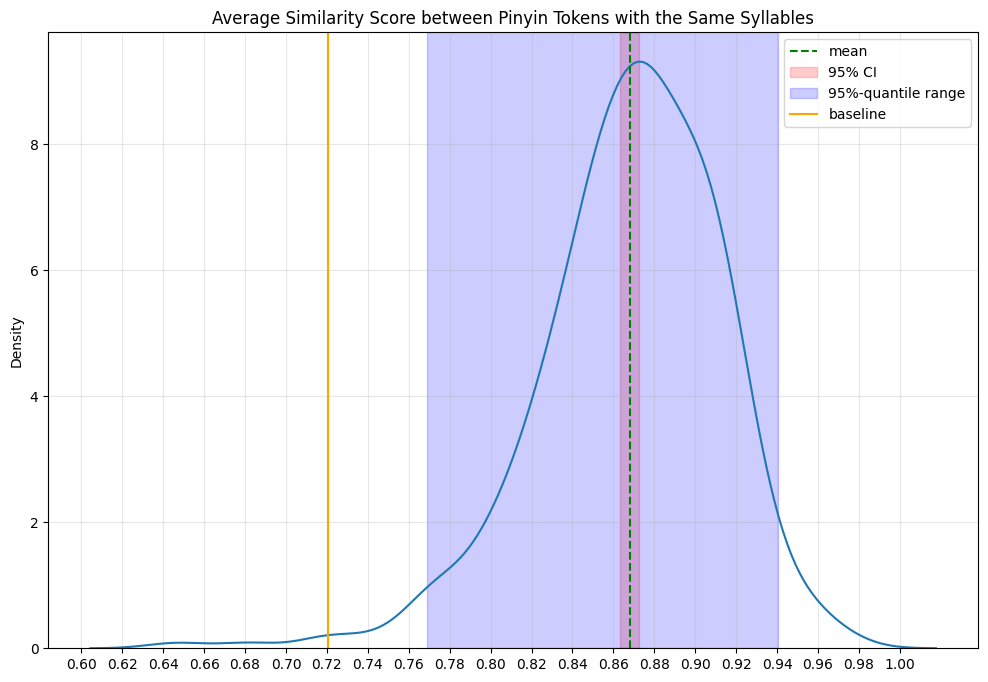

In [49]:
plt.figure(figsize=(12, 8))
plt.title("Average Similarity Score between Pinyin Tokens with the Same Syllables")

print(f"Average score of same syllable group: mean = {same_syllable_sims.mean():.3f} ± {same_syllable_sims.std():.3f}, CI = [{same_syllable_sims.quantile(0.05):.3f}, {same_syllable_sims.quantile(0.95):.3f}]")

plt.xticks(np.arange(0, 1.02, 0.02))

sns.kdeplot(same_syllable_sims)


n = len(same_syllable_sims)
confidence = 0.95

mean = same_syllable_sims.mean()
se = sem(same_syllable_sims) if n > 1 else 0.0
ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0

plt.axvline(mean, linestyle='--', color='green', label='mean')
plt.axvspan(mean-ci, mean+ci, alpha=0.2, color='red', label='95% CI')
plt.axvspan(same_syllable_sims.quantile(0.025), same_syllable_sims.quantile(0.975), alpha=0.2, color='blue', label='95%-quantile range')
plt.axvline(baseline_score, color='orange', label='baseline')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [50]:
import numpy as np
from itertools import combinations
from scipy.stats import sem, t

def get_tone_from_token(token):
    """Extract tone from pinyin token. Returns 1-5."""
    return int(token[-1])

def same_tone_similarity(emb_map, tone, confidence=0.95, sample_size=None):
    """
    Compute pairwise cosine similarities for all tokens with a given tone.
    
    Args:
        emb_map: dict {token: embedding vector}
        tone: int 1-4 or 0 for neutral
        confidence: confidence level for CI
        sample_size: if provided, randomly sample this many pairs (for large groups)
    Returns:
        dict with mean, std, ci_lower, ci_upper, count (number of pairs)
    """
    tokens = [tok for tok in emb_map.keys() if get_tone_from_token(tok) == tone]
    if len(tokens) < 2:
        return {'mean': None, 'std': None, 'ci_lower': None, 'ci_upper': None, 'count': 0}
    
    if sample_size and len(tokens) > sample_size:
        # Sample pairs (not all combinations)
        pairs = []
        while len(pairs) < sample_size:
            t1, t2 = np.random.choice(tokens, 2, replace=False)
            pairs.append((t1, t2))
    else:
        pairs = list(combinations(tokens, 2))
    
    sims = [cosine_similarity(emb_map[t1], emb_map[t2]) for t1, t2 in pairs]
    sims = np.array(sims)
    mean = np.mean(sims)
    std = np.std(sims, ddof=1)
    n = len(sims)
    se = sem(sims) if n > 1 else 0.0
    ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0
    return {
        'sims': sims,
        'mean': mean,
        'std': std,
        'ci_lower': mean - ci,
        'ci_upper': mean + ci,
        'count': n
    }

Tone 1: mean = 0.7759 ± 0.0645, CI = [0.7753, 0.7765], pairs = 41905
Tone 2: mean = 0.7161 ± 0.0808, CI = [0.7151, 0.7171], pairs = 26335
Tone 3: mean = 0.7205 ± 0.0866, CI = [0.7196, 0.7214], pairs = 34191
Tone 4: mean = 0.7706 ± 0.0646, CI = [0.7701, 0.7712], pairs = 46360
Tone 5: mean = 0.7862 ± 0.0666, CI = [0.7733, 0.7991], pairs = 105


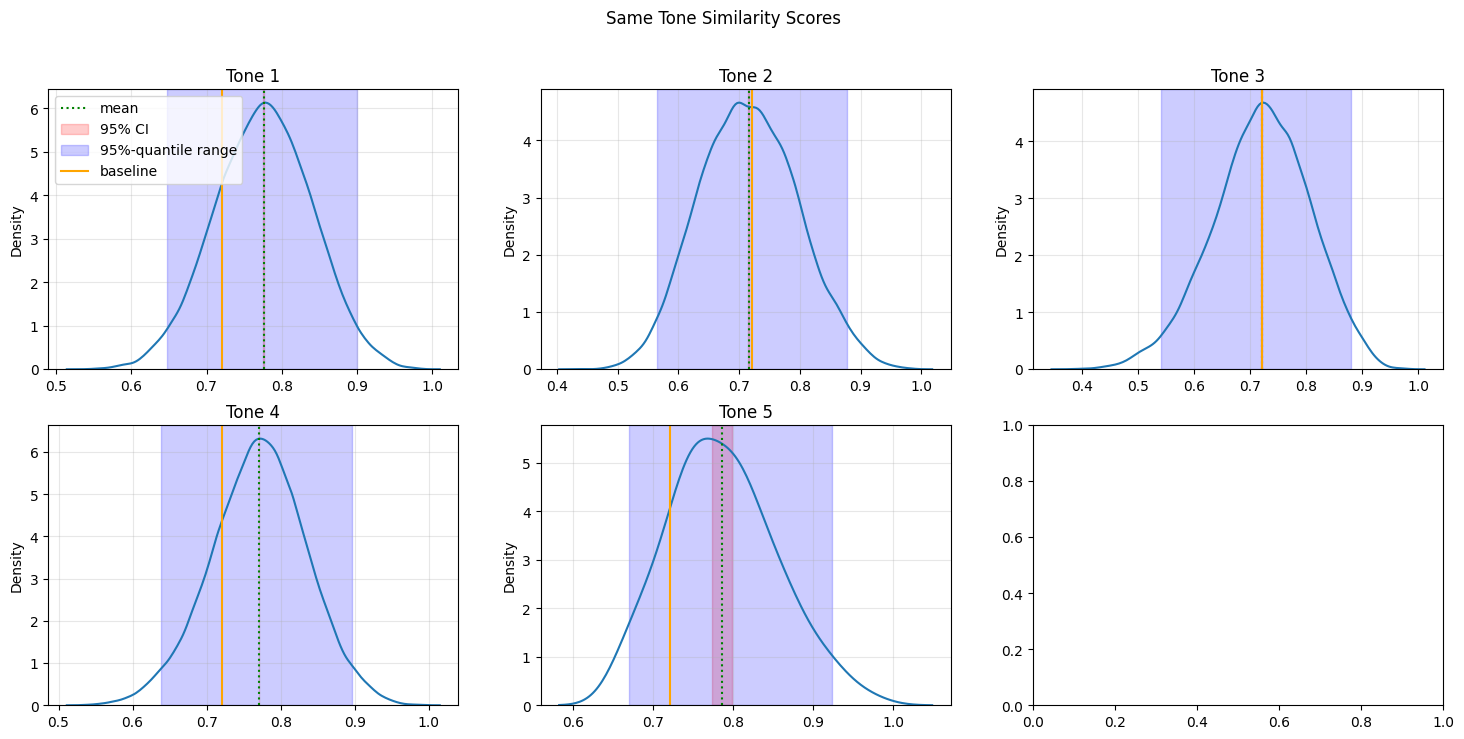

In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18, 8))

fig.suptitle("Same Tone Similarity Scores")

for i, tone in enumerate([1,2,3,4,5]):
    res = same_tone_similarity(embedding_map, tone)

    ax_i = ax[i // 3, i % 3]

    ax_i.set_title(f"Tone {tone}")
    sns.kdeplot(res['sims'], ax=ax_i)

    ax_i.axvline(res['mean'], color='green', linestyle=':', label='mean')
    ax_i.axvspan(res['ci_lower'], res['ci_upper'], alpha=0.2, color='red', label='95% CI')
    ax_i.axvspan(np.quantile(res['sims'], 0.025), np.quantile(res['sims'], 0.975), alpha=0.2, color='blue', label='95%-quantile range')
    ax_i.axvline(baseline_score, color='orange', label='baseline')

    ax_i.grid(True, alpha=0.3)

    if i == 0:
        ax_i.legend()

    print(f"Tone {tone}: mean = {res['mean']:.4f} ± {res['std']:.4f}, CI = [{res['ci_lower']:.4f}, {res['ci_upper']:.4f}], pairs = {res['count']}")

In [52]:
from collections import defaultdict

same_initial_tokens = defaultdict(list)
same_final_tokens = defaultdict(list)

for pinyin_token in embedding_map.keys():
    ini, final, tone = decompose_pinyin(pinyin_token)

    same_initial_tokens[ini].append(pinyin_token)
    same_final_tokens[final].append(pinyin_token)

initial: mean = 0.762 ± 0.005, CI = [0.752, 0.772]
final: mean = 0.818 ± 0.007, CI = [0.804, 0.832]


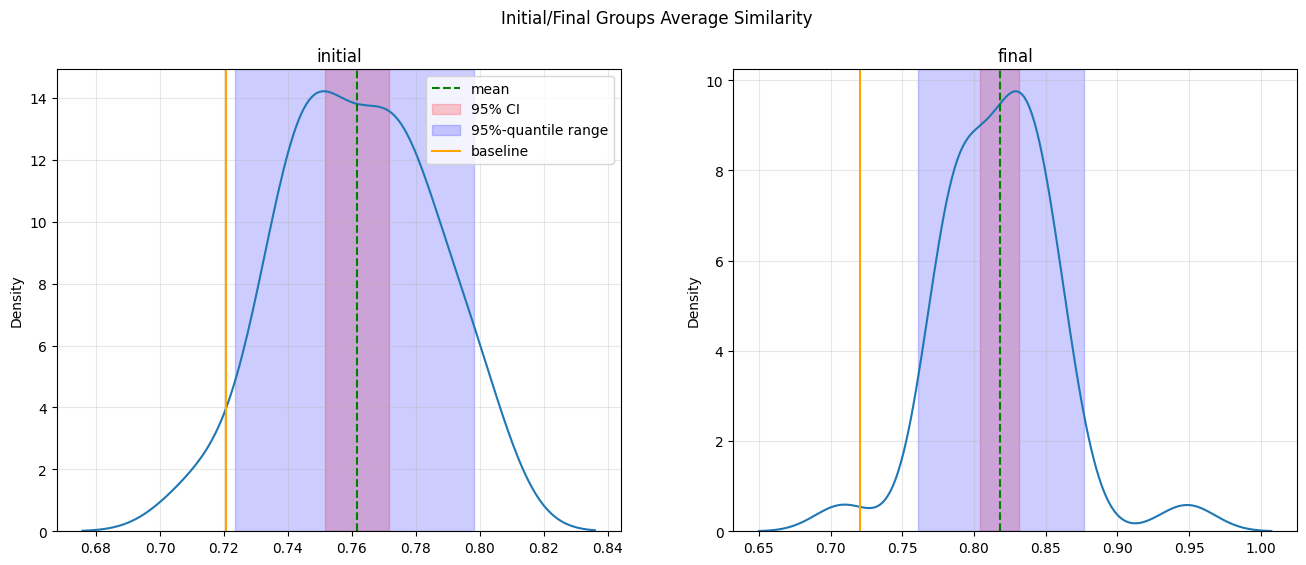

In [53]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

fig.suptitle("Initial/Final Groups Average Similarity")

for i, (name, group) in enumerate([('initial', same_initial_tokens), ('final', same_final_tokens)]):

    mean_scores = []
    
    for subgroup in group.values():
        res = intra_group_similarity(subgroup, embedding_map)
        mean_scores.append(res['mean'])

    ax_i = ax[i]

    ax_i.set_title(name)
    sns.kdeplot(mean_scores, ax=ax_i)

    n = len(mean_scores)
    confidence = 0.95

    mean = np.mean(mean_scores)
    se = sem(mean_scores) if n > 1 else 0.0
    ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0

    ax_i.axvline(mean, color='green', linestyle='--', label='mean')
    ax_i.axvspan(mean-ci, mean+ci, alpha=0.2, color='red', label='95% CI')
    ax_i.axvspan(np.quantile(mean_scores, 0.025), np.quantile(mean_scores, 0.975), alpha=0.2, color='blue', label='95%-quantile range')
    ax_i.axvline(baseline_score, color='orange', label='baseline')
    

    ax_i.grid(True, alpha=0.3)

    if i == 0:
        ax_i.legend()
    print(f"{name}: mean = {mean:.3f} ± {se:.3f}, CI = [{mean-ci:.3f}, {mean+ci:.3f}]")

### Dimensionality Reduction

In [54]:
import numpy as np
import pandas as pd

tokens = list(embedding_map.keys())
X = np.stack([embedding_map[t] for t in tokens])   # shape (n_samples, n_features)

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (1102, 1024)


In [55]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_var = pca.explained_variance_ratio_
cumulative = np.cumsum(explained_var)

print("Explained variance ratio (first 10):")
for i, ev in enumerate(explained_var[:10]):
    print(f"PC{i+1}: {ev:.4f}")

# Number of components to reach 90% variance
n_90 = np.argmax(cumulative >= 0.90) + 1
print(f"\nNumber of components to explain 90% variance: {n_90}")
print(f"Cumulative variance at {n_90} components: {cumulative[n_90-1]:.4f}")

Explained variance ratio (first 10):
PC1: 0.0863
PC2: 0.0698
PC3: 0.0594
PC4: 0.0553
PC5: 0.0488
PC6: 0.0384
PC7: 0.0334
PC8: 0.0292
PC9: 0.0290
PC10: 0.0266

Number of components to explain 90% variance: 91
Cumulative variance at 91 components: 0.9001


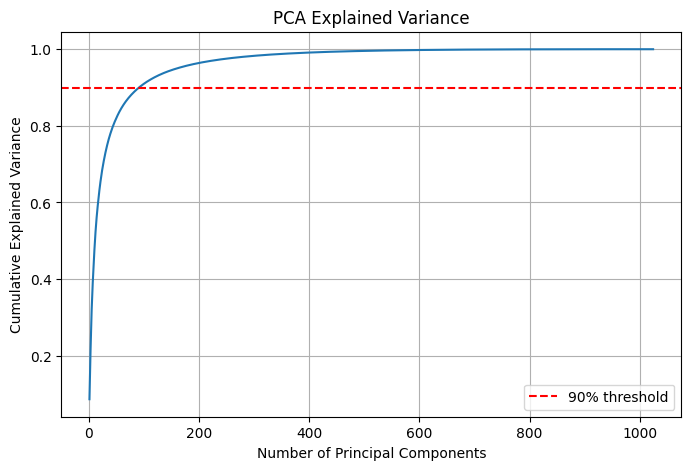

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative)+1), cumulative, linestyle='-')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Take first 2 principal components
X_pca_2d = X_pca[:, :2]


df = pd.DataFrame({
    'token': tokens,
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'initial': [token_info[t]['initial'] for t in tokens],
    'final': [token_info[t]['final'] for t in tokens],
    'tone': [token_info[t]['tone'] for t in tokens]
})

# Map tone numbers to labels for legend
tone_labels = {'1': 'Tone 1', '2': 'Tone 2', '3': 'Tone 3', '4': 'Tone 4', '5': 'Neutral'}
df['tone_label'] = df['tone'].map(tone_labels)

# Encode categorical columns to numeric codes
encoders = {}
for col in ['initial', 'final', 'tone_label']:
    le = LabelEncoder()
    df[col + '_code'] = le.fit_transform(df[col])
    encoders[col] = le

# Print mapping for reference
for col, le in encoders.items():
    print(f"\n{col} mapping:")
    for i, name in enumerate(le.classes_):
        print(f"  {i}: {name}")


initial mapping:
  0: 
  1: b
  2: c
  3: ch
  4: d
  5: f
  6: g
  7: h
  8: j
  9: k
  10: l
  11: m
  12: n
  13: p
  14: q
  15: r
  16: s
  17: sh
  18: t
  19: x
  20: z
  21: zh

final mapping:
  0: a
  1: ai
  2: an
  3: ang
  4: ao
  5: e
  6: ei
  7: en
  8: eng
  9: er
  10: i
  11: ia
  12: ian
  13: iang
  14: iao
  15: ie
  16: in
  17: ing
  18: iong
  19: iu
  20: o
  21: ong
  22: ou
  23: u
  24: ua
  25: uai
  26: uan
  27: uang
  28: ui
  29: un
  30: uo
  31: v
  32: van
  33: ve
  34: vn

tone_label mapping:
  0: Neutral
  1: Tone 1
  2: Tone 2
  3: Tone 3
  4: Tone 4


In [58]:
import plotly.graph_objects as go
import plotly.express as px

# Get unique values and create discrete colorscales
def get_discrete_colorscale(categories):
    """Return a colorscale that maps integer codes to distinct colors."""
    n = len(categories)
    # Use Plotly qualitative colors
    colors = px.colors.qualitative.Plotly[:n]
    # Build colorscale: each category gets a solid color block
    step = 1.0 / n
    colorscale = []
    for i, col in enumerate(colors):
        # Start of block
        colorscale.append((i * step, col))
        # End of block (same color)
        colorscale.append(((i+1) * step, col))

    return colorscale

# Precompute colorscales for each column
color_scales = {}
for col in ['initial', 'final', 'tone_label']:
    categories = encoders[col].classes_
    color_scales[col] = get_discrete_colorscale(categories)

# Default column for initial coloring
default_col = 'initial'
df_col_code = default_col + '_code'
color_scale = color_scales[default_col]

# Create figure
fig = go.Figure()

# Add trace with default coloring
fig.add_trace(go.Scattergl(
    x=df['PC1'],
    y=df['PC2'],
    mode='markers',
    marker=dict(
        color=df[df_col_code],
        colorscale=color_scale,
        cmin=0,
        cmax=len(encoders[default_col].classes_) - 1,
        size=5,
        opacity=0.6,
        showscale=True,
        colorbar=dict(title=default_col.capitalize())
    ),
    text=df['token'],
    hovertemplate='<b>%{text}</b><br>Initial: %{customdata[0]}<br>Final: %{customdata[1]}<br>Tone: %{customdata[2]}<extra></extra>',
    customdata=df[['initial','final','tone_label']].values
))

fig.update_layout(
    title='PCA of Acoustic Embeddings (First 2 Components)',
    xaxis_title='PC1',
    yaxis_title='PC2',
    width=1000,
    height=700,
    hovermode='closest'
)

# Dropdown buttons
buttons = []
for col in ['initial', 'final', 'tone_label']:
    col_code = col + '_code'
    buttons.append(
        dict(
            label=col.capitalize(),
            method='restyle',
            args=[
                {'marker.color': [df[col_code]],
                 'marker.colorscale': [color_scales[col]],
                 'marker.cmax': [len(encoders[col].classes_) - 1],
                 'marker.colorbar.title': [col.capitalize()]}
            ]
        )
    )

fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.1,
        y=1.1,
        xanchor='left',
        yanchor='top'
    )]
)

fig.show()

In [59]:
!pip install umap-learn   # if not already installed

import umap
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
import plotly.graph_objects as go
import plotly.express as px

2026-03-31 15:21:51.927335: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774970512.151229      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774970512.223316      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774970512.719283      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774970512.719321      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774970512.719338      17 computation_placer.cc:177] computation placer alr

In [60]:
tokens = list(embedding_map.keys())
X = np.stack([embedding_map[t] for t in tokens])   # shape (n_samples, n_features)

# Standardization can help UMAP, but UMAP is robust.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")

Feature matrix shape: (1102, 1024)


In [61]:
# Parameters
n_neighbors = 15
min_dist = 0.1
n_components = 2
random_state = 42

reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    verbose=True
)

X_umap = reducer.fit_transform(X_scaled)
print(f"UMAP embedding shape: {X_umap.shape}")

UMAP(n_jobs=1, random_state=42, verbose=True)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Tue Mar 31 15:22:07 2026 Construct fuzzy simplicial set
Tue Mar 31 15:22:08 2026 Finding Nearest Neighbors
Tue Mar 31 15:22:11 2026 Finished Nearest Neighbor Search
Tue Mar 31 15:22:12 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Tue Mar 31 15:22:14 2026 Finished embedding
UMAP embedding shape: (1102, 2)


In [62]:
df = pd.DataFrame({
    'token': tokens,
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'initial': [token_info[t]['initial'] for t in tokens],
    'final': [token_info[t]['final'] for t in tokens],
    'tone': [token_info[t]['tone'] for t in tokens]
})

# Map tone numbers to labels for legend
tone_labels = {'5': 'Neutral', '1': 'Tone 1', '2': 'Tone 2', '3': 'Tone 3', '4': 'Tone 4'}
df['tone_label'] = df['tone'].map(tone_labels)

# Encode categorical columns to numeric codes for plotting
encoders = {}
for col in ['initial', 'final', 'tone_label']:
    le = LabelEncoder()
    df[col + '_code'] = le.fit_transform(df[col])
    encoders[col] = le

# Print category mapping for reference
for col, le in encoders.items():
    print(f"\n{col} mapping:")
    for i, name in enumerate(le.classes_):
        print(f"  {i}: {name}")


initial mapping:
  0: 
  1: b
  2: c
  3: ch
  4: d
  5: f
  6: g
  7: h
  8: j
  9: k
  10: l
  11: m
  12: n
  13: p
  14: q
  15: r
  16: s
  17: sh
  18: t
  19: x
  20: z
  21: zh

final mapping:
  0: a
  1: ai
  2: an
  3: ang
  4: ao
  5: e
  6: ei
  7: en
  8: eng
  9: er
  10: i
  11: ia
  12: ian
  13: iang
  14: iao
  15: ie
  16: in
  17: ing
  18: iong
  19: iu
  20: o
  21: ong
  22: ou
  23: u
  24: ua
  25: uai
  26: uan
  27: uang
  28: ui
  29: un
  30: uo
  31: v
  32: van
  33: ve
  34: vn

tone_label mapping:
  0: Neutral
  1: Tone 1
  2: Tone 2
  3: Tone 3
  4: Tone 4


In [63]:
# Build discrete colorscales for each categorical column
def get_discrete_colorscale(categories):
    n = len(categories)
    colors = px.colors.qualitative.Plotly[:n]
    step = 1.0 / n
    colorscale = []
    for i, col in enumerate(colors):
        colorscale.append((i * step, col))
        colorscale.append(((i+1) * step, col))
    return colorscale

color_scales = {}
for col in ['initial', 'final', 'tone_label']:
    color_scales[col] = get_discrete_colorscale(encoders[col].classes_)

# Default column
default_col = 'initial'
default_code = default_col + '_code'
default_scale = color_scales[default_col]

fig = go.Figure()

fig.add_trace(go.Scattergl(
    x=df['UMAP1'],
    y=df['UMAP2'],
    mode='markers',
    marker=dict(
        color=df[default_code],
        colorscale=default_scale,
        cmin=0,
        cmax=len(encoders[default_col].classes_) - 1,
        size=5,
        opacity=0.6,
        showscale=True,
        colorbar=dict(title=default_col.capitalize())
    ),
    text=df['token'],
    hovertemplate='<b>%{text}</b><br>Initial: %{customdata[0]}<br>Final: %{customdata[1]}<br>Tone: %{customdata[2]}<extra></extra>',
    customdata=df[['initial','final','tone_label']].values
))

fig.update_layout(
    title='UMAP of Acoustic Embeddings',
    xaxis_title='UMAP1',
    yaxis_title='UMAP2',
    width=1000,
    height=700,
    hovermode='closest'
)

# Dropdown buttons
buttons = []
for col in ['initial', 'final', 'tone_label']:
    col_code = col + '_code'
    buttons.append(
        dict(
            label=col.capitalize(),
            method='restyle',
            args=[
                {'marker.color': [df[col_code]],
                 'marker.colorscale': [color_scales[col]],
                 'marker.cmax': [len(encoders[col].classes_) - 1],
                 'marker.colorbar.title': [col.capitalize()]}
            ]
        )
    )

fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.1,
        y=1.1,
        xanchor='left',
        yanchor='top'
    )]
)

fig.show()

In [64]:
# Save the PCA or UMAP figure
fig.write_html('pca_plot.html')
# or
fig.write_html('umap_plot.html')

### Clustering Analysis

In [65]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
import numpy as np


# Extract labels for each category
y_initial = np.array([token_info[t]['initial'] for t in tokens])
y_final = np.array([token_info[t]['final'] for t in tokens])
y_tone = np.array([token_info[t]['tone'] for t in tokens])

# Encode labels to numeric

le_initial = LabelEncoder()
le_final = LabelEncoder()
le_tone = LabelEncoder()

y_initial_enc = le_initial.fit_transform(y_initial)
y_final_enc = le_final.fit_transform(y_final)
y_tone_enc = le_tone.fit_transform(y_tone)

# Compute silhouette scores
sil_initial = silhouette_score(X_scaled, y_initial_enc, metric='cosine')
sil_final = silhouette_score(X_scaled, y_final_enc, metric='cosine')
sil_tone = silhouette_score(X_scaled, y_tone_enc, metric='cosine')

print(f"Silhouette Score for Initial Categories: {sil_initial:.4f}")
print(f"Silhouette Score for Final Categories:   {sil_final:.4f}")
print(f"Silhouette Score for Tone Categories:    {sil_tone:.4f}")

Silhouette Score for Initial Categories: 0.0448
Silhouette Score for Final Categories:   0.0769
Silhouette Score for Tone Categories:    0.0583
